<a href="https://colab.research.google.com/github/Charan290904/Charan-ML-2/blob/main/BaggingAndBoosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Load dataset (Breast Cancer Wisconsin - binary classification, 30 features, 569 samples)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Shape:", X.shape)
print("Class distribution:\n", y.value_counts())
X.head()

Shape: (569, 30)
Class distribution:
 target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (455, 30) Test size: (114, 30)


In [ ]:
base_tree = DecisionTreeClassifier(random_state=42)

models = {
    "Decision Tree (baseline)": DecisionTreeClassifier(random_state=42),
    "Bagging (DT base)": BaggingClassifier(estimator=base_tree, n_estimators=100, random_state=42),
    "Random Forest (Bagging variant)": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "CV Accuracy (5-fold)": cv_score
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,CV Accuracy (5-fold)
2,Random Forest (Bagging variant),0.956140,0.958904,0.972222,0.965517,0.953846
4,Gradient Boosting,0.956140,0.946667,0.986111,0.965986,0.956044
3,AdaBoost,0.956140,0.946667,0.986111,0.965986,0.973626
1,Bagging (DT base),0.938596,0.945205,0.958333,0.951724,0.951648
0,Decision Tree (baseline),0.912281,0.955882,0.902778,0.928571,0.909890


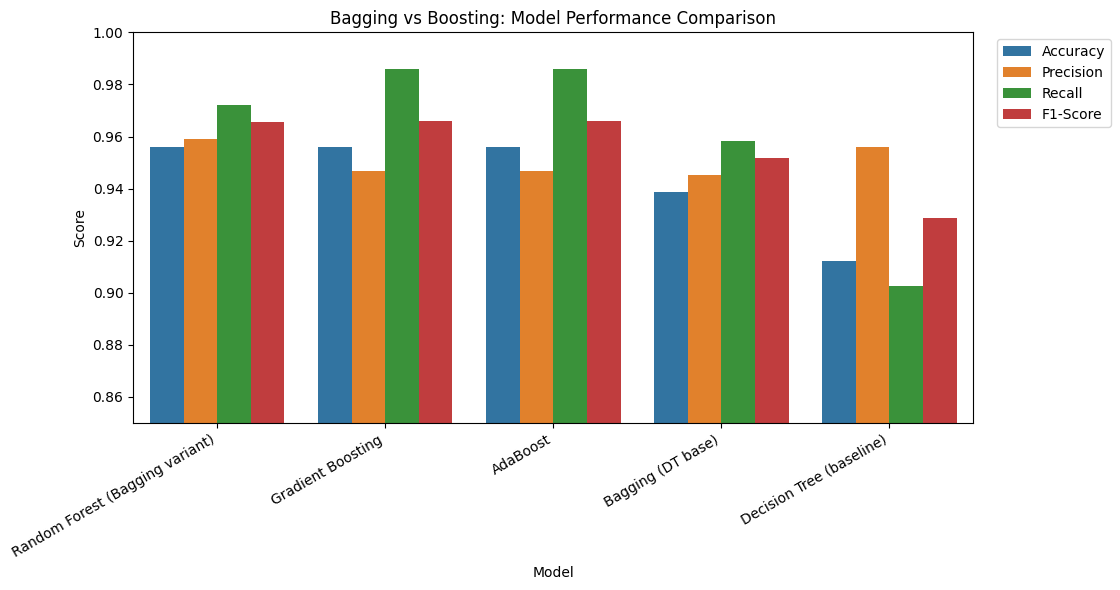

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
results_melted = results_df.melt(id_vars="Model",
                                   value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
                                   var_name="Metric", value_name="Score")

sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", ax=ax)
plt.xticks(rotation=30, ha='right')
plt.title("Bagging vs Boosting: Model Performance Comparison")
plt.ylim(0.85, 1.0)
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

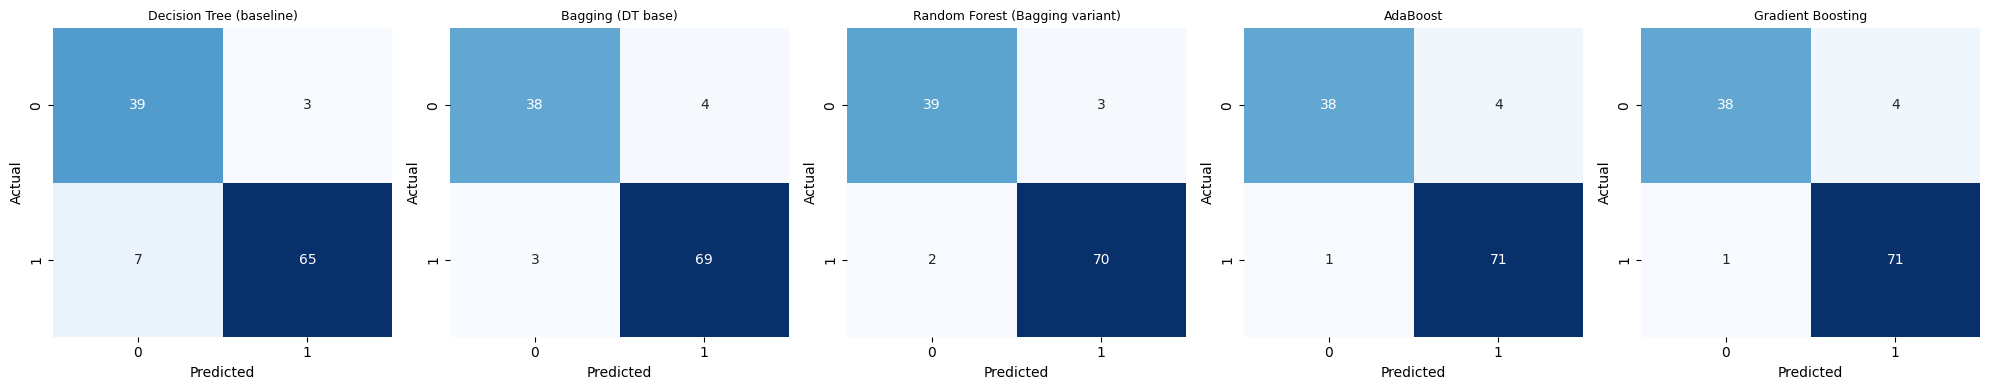

In [ ]:
fig, axes = plt.subplots(1, len(models), figsize=(20, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"Best Model: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

Best Model: Random Forest (Bagging variant)

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

